In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import re
import pickle
from gensim.models import KeyedVectors, Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from deep_translator import GoogleTranslator

# Проведем предобработку датасета

In [2]:
comparsion_dataset = pd.read_csv('./data/news.csv')

In [3]:
comparsion_dataset.head(3)

,source,title,text,publication_date,rubric,subrubric,tags
0,lenta.ru,Синий богатырь,В 1930-е годы Советский Союз охватила лихорадк...,2020-08-30T00:01:00+03:00,Экономика,Госэкономика,NaN
1,lenta.ru,Загитова согласилась вести «Ледниковый период»,Олимпийская чемпионка по фигурному катанию Ал...,2020-08-31T20:04:00+03:00,Спорт,Зимние виды,NaN
2,lenta.ru,Объяснена опасность однообразного питания,Российский врач-диетолог Римма Мойсенко объясн...,2020-08-31T20:07:00+03:00,Из жизни,Еда,NaN


In [4]:
comparsion_dataset.drop(columns=['source', 'publication_date', 'rubric', 'subrubric', 'tags'], inplace=True)

In [5]:
try:
    russian_stopwords = stopwords.words('russian')
except:
    nltk.download('stopwords')
    russian_stopwords = stopwords.words('russian')

In [6]:
def combine_features(row):
    headline = row['headline_clean']
    body_words = row['body_clean'].split()
    body = ' '.join(body_words)
    return f"{headline} {body}"

def preprocess_text(text):
    if not isinstance(text, str) or len(text) == 0:
        return ""
    
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^а-яё\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    words = text.split()
    words = [word for word in words if word not in russian_stopwords and len(word) > 2]
    
    return ' '.join(words)

In [7]:
comparsion_dataset = comparsion_dataset.rename(columns={'title': 'Headline', 'text': 'articleBody'})

comparsion_dataset['headline_clean'] = comparsion_dataset['Headline'].apply(preprocess_text)
comparsion_dataset['body_clean'] = comparsion_dataset['articleBody'].apply(preprocess_text)

comparsion_dataset['combined_text'] = comparsion_dataset.apply(combine_features, axis=1)

comparsion_dataset = comparsion_dataset[comparsion_dataset['combined_text'].str.len() > 10].reset_index(drop=True)

sentences = [text.split() for text in comparsion_dataset['body_clean']] + [text.split() for text in comparsion_dataset['headline_clean']]
w2v = Word2Vec(sentences, vector_size=300, window=3, min_count=3, sg=1, workers=4, epochs=10)
kv = w2v.wv

# Logistic regression TF-IDF сравенение на 500 строках

In [8]:
comparsion_dataset = comparsion_dataset.head(100).copy()
print(f"Работаем с первыми {len(comparsion_dataset)} строками датасета")
comparsion_dataset

Работаем с первыми 100 строками датасета


,Headline,articleBody,headline_clean,body_clean,combined_text
0,Синий богатырь,В 1930-е годы Советский Союз охватила лихорадк...,синий богатырь,годы советский союз охватила лихорадка десятил...,синий богатырь годы советский союз охватила ли...
1,Загитова согласилась вести «Ледниковый период»,Олимпийская чемпионка по фигурному катанию Ал...,загитова согласилась вести ледниковый период,олимпийская чемпионка фигурному катанию алина ...,загитова согласилась вести ледниковый период о...
2,Объяснена опасность однообразного питания,Российский врач-диетолог Римма Мойсенко объясн...,объяснена опасность однообразного питания,российский врач диетолог римма мойсенко объясн...,объяснена опасность однообразного питания росс...
3,«Предохраняться? А зачем?»,В 2019 году телеканал «Ю» запустил адаптацию з...,предохраняться,году телеканал запустил адаптацию знаменитого ...,предохраняться году телеканал запустил адаптац...
4,Ефремов систематически употреблял наркотики,Актер Михаил Ефремов систематически употребл...,ефремов систематически употреблял наркотики,актер михаил ефремов систематически употреблял...,ефремов систематически употреблял наркотики ак...
...,...,...,...,...,...
95,Всю поездку Путина по «Тавриде» показали на видео,"В сети появилось полное видео, на котором запе...",поездку путина тавриде показали видео,сети появилось полное видео котором запечатлен...,поездку путина тавриде показали видео сети поя...
96,Школьники среди коренных народов Севера оказал...,Старшеклассники из числа представителей малочи...,школьники среди коренных народов севера оказал...,старшеклассники числа представителей малочисле...,школьники среди коренных народов севера оказал...
97,В Минске массово задержали журналистов,На площади Свободы в Минске милиция массово за...,минске массово задержали журналистов,площади свободы минске милиция массово задержа...,минске массово задержали журналистов площади с...
98,Стало известно о случае вероятного излечения о...,"Женщина, у которой почти 30 лет назад был диаг...",стало известно случае вероятного излечения вич...,женщина которой лет назад диагностирован вич в...,стало известно случае вероятного излечения вич...


# Проверим точность на русском датасете

In [9]:
# Загружаем модель и векторизатор (русская модель, т.к. данные на русском языке)
log_reg = pickle.load(open('models/logistic_regression_model_tf.pkl', 'rb'))
tfidf_vectorizer = pickle.load(open('models/tfidf_vectorizer_tf.pkl', 'rb'))

In [10]:
# Преобразуем текст в TF-IDF векторы
X_test = tfidf_vectorizer.transform(comparsion_dataset['combined_text'])

# Делаем предсказание
y_pred_russian_500_tf_idf_logreg = log_reg.predict(X_test)

In [11]:
# Подсчитываем статистику предсказаний
total_rows = len(y_pred_russian_500_tf_idf_logreg)
predictions = np.sum(y_pred_russian_500_tf_idf_logreg == 1)
percentage = (predictions / total_rows) * 100

print(f"Общее количество строк в датасете: {total_rows}")
print(f"\nПредсказания со значением 1: {predictions} ({percentage:.2f}%)")


Общее количество строк в датасете: 100

Предсказания со значением 1: 75 (75.00%)


# Проверим точность на английском датасете

In [12]:
log_reg_en = pickle.load(open('models/logistic_regression_model_tf_eng.pkl', 'rb'))
tfidf_vectorizer_en = pickle.load(open('models/tfidf_vectorizer_tf_eng.pkl', 'rb'))

In [13]:
def translate_to_en(text):
    try:
        return GoogleTranslator(source='auto', target='en').translate(text)
    except Exception as e:
        return text 

In [14]:
# Переводим combined_text на английский язык
import time

print("Переводим тексты на английский язык...")
print(f"Всего строк для перевода: {len(comparsion_dataset)}")

start_time = time.time()
translated_texts = []

for idx, text in enumerate(comparsion_dataset['combined_text'], 1):
    item_start = time.time()
    translated = translate_to_en(text)
    translated_texts.append(translated)
    item_time = time.time() - item_start

comparsion_dataset['combined_text_en'] = translated_texts

total_time = time.time() - start_time
print(f"\n\nПеревод завершен! Общее время: {int(total_time // 60)}м {int(total_time % 60)}с")

# Преобразуем переведенный текст в TF-IDF векторы
X_test = tfidf_vectorizer_en.transform(comparsion_dataset['combined_text_en'])

# Делаем предсказание
y_pred_english_500_tf_idf_logreg = log_reg_en.predict(X_test)

Переводим тексты на английский язык...
Всего строк для перевода: 100


Перевод завершен! Общее время: 2м 10с


In [15]:
# Подсчитываем статистику предсказаний
total_rows = len(y_pred_english_500_tf_idf_logreg)
predictions_1 = np.sum(y_pred_english_500_tf_idf_logreg == 1)
percentage_1 = (predictions_1 / total_rows) * 100

print(f"Общее количество строк в датасете: {total_rows}")
print(f"\nПредсказания со значением 1: {predictions_1} ({percentage_1:.2f}%)")

Общее количество строк в датасете: 100

Предсказания со значением 1: 39 (39.00%)


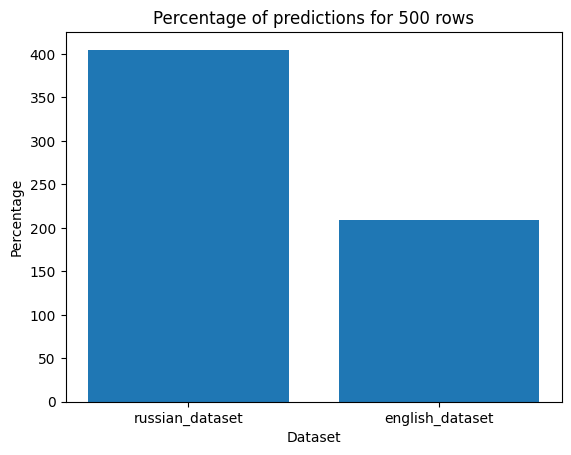

In [ ]:
percentage_500_names = ['russian_dataset', 'english_dataset']
percentage_500 = [predictions, predictions_1]

plt.bar(percentage_500_names, percentage_500)
plt.xlabel('Dataset')
plt.ylabel('Percentage')
plt.title('Percentage of predictions for 500 rows')
plt.show()


# Logistic regression TF-IDF сравенение на 100 строк

In [ ]:
comparsion_dataset = comparsion_dataset.head(50).copy()
print(f"Работаем с первыми {len(comparsion_dataset)} строками датасета")

Работаем с первыми 50 строками датасета


# Проверим точность на русском датасете

In [ ]:
# Преобразуем текст в TF-IDF векторы
X_test = tfidf_vectorizer.transform(comparsion_dataset['combined_text'])

# Делаем предсказание
y_pred_russian_50_tf_idf_logreg = log_reg.predict(X_test)

In [ ]:
# Подсчитываем статистику предсказаний
total_rows = len(y_pred_russian_50_tf_idf_logreg)
predictions = np.sum(y_pred_russian_50_tf_idf_logreg == 1)
percentage = (predictions / total_rows) * 100

print(f"Общее количество строк в датасете: {total_rows}")
print(f"\nПредсказания со значением 1: {predictions} ({percentage:.2f}%)")


Общее количество строк в датасете: 50

Предсказания со значением 1: 39 (78.00%)


# Проверим точность на английском датасете

In [ ]:
# Переводим combined_text на английский язык
import time

print("Переводим тексты на английский язык...")
print(f"Всего строк для перевода: {len(comparsion_dataset)}")

start_time = time.time()
translated_texts = []

for idx, text in enumerate(comparsion_dataset['combined_text'], 1):
    item_start = time.time()
    translated = translate_to_en(text)
    translated_texts.append(translated)
    item_time = time.time() - item_start

comparsion_dataset['combined_text_en'] = translated_texts

total_time = time.time() - start_time
print(f"\n\nПеревод завершен! Общее время: {int(total_time // 60)}м {int(total_time % 60)}с")

# Преобразуем переведенный текст в TF-IDF векторы
X_test = tfidf_vectorizer_en.transform(comparsion_dataset['combined_text_en'])

# Делаем предсказание
y_pred_english_100_tf_idf_logreg = log_reg_en.predict(X_test)

Переводим тексты на английский язык...
Всего строк для перевода: 50


Перевод завершен! Общее время: 1м 5с


In [ ]:
# Подсчитываем статистику предсказаний
total_rows = len(y_pred_english_100_tf_idf_logreg)
predictions_1 = np.sum(y_pred_english_100_tf_idf_logreg == 1)
percentage_1 = (predictions_1 / total_rows) * 100

print(f"Общее количество строк в датасете: {total_rows}")
print(f"\nПредсказания со значением 1: {predictions_1} ({percentage_1:.2f}%)")

Общее количество строк в датасете: 50

Предсказания со значением 1: 15 (30.00%)


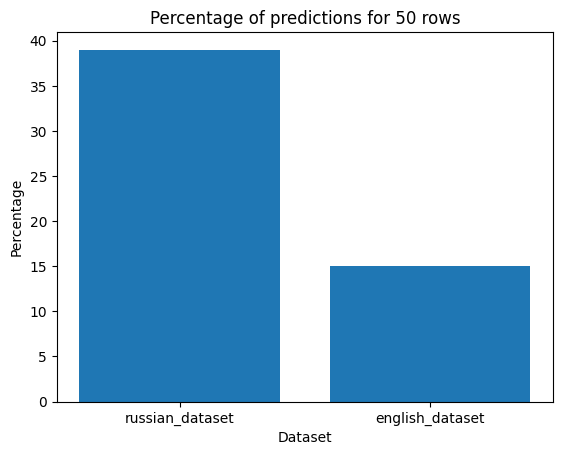

In [ ]:
percentage_50_names = ['russian_dataset', 'english_dataset']
percentage_50 = [predictions, predictions_1]

plt.bar(percentage_50_names, percentage_50)
plt.xlabel('Dataset')
plt.ylabel('Percentage')
plt.title('Percentage of predictions for 50 rows (Logisic Regression TF-IDF)')
plt.show()


# Naive Bayes TF-IDF сравнение на 500 строках


In [ ]:
# Загружаем датасет на 500 строк для Naive Bayes
comparsion_dataset_nb = comparsion_dataset.head(500).copy() if len(comparsion_dataset) > 500 else comparsion_dataset.copy()
print(f"Работаем с первыми {len(comparsion_dataset_nb)} строками датасета для Naive Bayes")


## Проверим точность на русском датасете (Naive Bayes TF-IDF)


In [ ]:
# Загружаем модель и векторизатор (русская модель Naive Bayes)
nb_model = pickle.load(open('models/naive_bayes_model_tf.pkl', 'rb'))
tfidf_vectorizer_nb = pickle.load(open('models/tfidf_vectorizer_tf.pkl', 'rb'))

# Преобразуем текст в TF-IDF векторы
X_test_nb = tfidf_vectorizer_nb.transform(comparsion_dataset_nb['combined_text'])

# Делаем предсказание
y_pred_russian_500_tf_idf_nb = nb_model.predict(X_test_nb)


In [ ]:
# Подсчитываем статистику предсказаний (Naive Bayes русская модель)
total_rows_nb_ru = len(y_pred_russian_500_tf_idf_nb)
predictions_nb_ru = np.sum(y_pred_russian_500_tf_idf_nb == 1)
percentage_nb_ru = (predictions_nb_ru / total_rows_nb_ru) * 100

print(f"Общее количество строк в датасете: {total_rows_nb_ru}")
print(f"\nПредсказания со значением 1: {predictions_nb_ru} ({percentage_nb_ru:.2f}%)")


## Проверим точность на английском датасете (Naive Bayes TF-IDF)


In [ ]:
# Загружаем модель и векторизатор (английская модель Naive Bayes)
nb_model_en = pickle.load(open('models/naive_bayes_model_tf_eng.pkl', 'rb'))
tfidf_vectorizer_nb_en = pickle.load(open('models/tfidf_vectorizer_tf_eng.pkl', 'rb'))

# Используем уже переведенный текст, если он есть, иначе переводим
if 'combined_text_en' not in comparsion_dataset_nb.columns:
    print("Переводим тексты на английский язык...")
    print(f"Всего строк для перевода: {len(comparsion_dataset_nb)}")
    
    start_time = time.time()
    translated_texts_nb = []
    
    for idx, text in enumerate(comparsion_dataset_nb['combined_text'], 1):
        translated = translate_to_en(text)
        translated_texts_nb.append(translated)
        
        elapsed_time = time.time() - start_time
        avg_time_per_item = elapsed_time / idx
        remaining_items = len(comparsion_dataset_nb) - idx
        estimated_remaining = avg_time_per_item * remaining_items
        
        elapsed_str = f"{int(elapsed_time // 60)}м {int(elapsed_time % 60)}с"
        remaining_str = f"{int(estimated_remaining // 60)}м {int(estimated_remaining % 60)}с"
        
        print(f"Прогресс: {idx}/{len(comparsion_dataset_nb)} | "
              f"Прошло: {elapsed_str} | "
              f"Осталось: ~{remaining_str}", end='\r')
    
    comparsion_dataset_nb['combined_text_en'] = translated_texts_nb
    
    total_time = time.time() - start_time
    print(f"\n\nПеревод завершен! Общее время: {int(total_time // 60)}м {int(total_time % 60)}с")

# Преобразуем переведенный текст в TF-IDF векторы
X_test_nb_en = tfidf_vectorizer_nb_en.transform(comparsion_dataset_nb['combined_text_en'])

# Делаем предсказание
y_pred_english_500_tf_idf_nb = nb_model_en.predict(X_test_nb_en)


In [ ]:
# Подсчитываем статистику предсказаний (Naive Bayes английская модель)
total_rows_nb_en = len(y_pred_english_500_tf_idf_nb)
predictions_nb_en = np.sum(y_pred_english_500_tf_idf_nb == 1)
percentage_nb_en = (predictions_nb_en / total_rows_nb_en) * 100

print(f"Общее количество строк в датасете: {total_rows_nb_en}")
print(f"\nПредсказания со значением 1: {predictions_nb_en} ({percentage_nb_en:.2f}%)")


---

In [ ]:
percentage_nb_tf_idf_names = ['russian_dataset', 'english_dataset']
percentage_nb_tf_idf = [predictions_nb_ru, predictions_nb_en]

plt.bar(percentage_nb_tf_idf_names, percentage_nb_tf_idf)
plt.xlabel('Dataset')
plt.ylabel('Percentage')
plt.title('Percentage of predictions for 50 rows (Naive Bayes TF-IDF)')
plt.show()


# Random Forest TF-IDF сравнение на 500 строках


In [ ]:
# Загружаем датасет на 500 строк для Random Forest
comparsion_dataset_rf = comparsion_dataset.head(500).copy() if len(comparsion_dataset) > 500 else comparsion_dataset.copy()
print(f"Работаем с первыми {len(comparsion_dataset_rf)} строками датасета для Random Forest")


## Проверим точность на русском датасете (Random Forest TF-IDF)


In [ ]:
# Загружаем модель и векторизатор (русская модель Random Forest)
rf_model = pickle.load(open('models/random_forest_model_tf.pkl', 'rb'))
tfidf_vectorizer_rf = pickle.load(open('models/tfidf_vectorizer_tf.pkl', 'rb'))

# Преобразуем текст в TF-IDF векторы
X_test_rf = tfidf_vectorizer_rf.transform(comparsion_dataset_rf['combined_text'])

# Делаем предсказание
y_pred_russian_500_tf_idf_rf = rf_model.predict(X_test_rf)


In [ ]:
# Подсчитываем статистику предсказаний (Random Forest русская модель)
total_rows_rf_ru = len(y_pred_russian_500_tf_idf_rf)
predictions_rf_ru = np.sum(y_pred_russian_500_tf_idf_rf == 1)
percentage_rf_ru = (predictions_rf_ru / total_rows_rf_ru) * 100

print(f"Общее количество строк в датасете: {total_rows_rf_ru}")
print(f"\nПредсказания со значением 1: {predictions_rf_ru} ({percentage_rf_ru:.2f}%)")


## Проверим точность на английском датасете (Random Forest TF-IDF)


In [ ]:
# Загружаем модель и векторизатор (английская модель Random Forest)
rf_model_en = pickle.load(open('models/random_forest_model_tf_eng.pkl', 'rb'))
tfidf_vectorizer_rf_en = pickle.load(open('models/tfidf_vectorizer_tf_eng.pkl', 'rb'))

# Используем уже переведенный текст, если он есть, иначе переводим
if 'combined_text_en' not in comparsion_dataset_rf.columns:
    print("Переводим тексты на английский язык...")
    print(f"Всего строк для перевода: {len(comparsion_dataset_rf)}")
    
    start_time = time.time()
    translated_texts_rf = []
    
    for idx, text in enumerate(comparsion_dataset_rf['combined_text'], 1):
        translated = translate_to_en(text)
        translated_texts_rf.append(translated)
        
        elapsed_time = time.time() - start_time
        avg_time_per_item = elapsed_time / idx
        remaining_items = len(comparsion_dataset_rf) - idx
        estimated_remaining = avg_time_per_item * remaining_items
        
        elapsed_str = f"{int(elapsed_time // 60)}м {int(elapsed_time % 60)}с"
        remaining_str = f"{int(estimated_remaining // 60)}м {int(estimated_remaining % 60)}с"
        
        print(f"Прогресс: {idx}/{len(comparsion_dataset_rf)} | "
              f"Прошло: {elapsed_str} | "
              f"Осталось: ~{remaining_str}", end='\r')
    
    comparsion_dataset_rf['combined_text_en'] = translated_texts_rf
    
    total_time = time.time() - start_time
    print(f"\n\nПеревод завершен! Общее время: {int(total_time // 60)}м {int(total_time % 60)}с")

# Преобразуем переведенный текст в TF-IDF векторы
X_test_rf_en = tfidf_vectorizer_rf_en.transform(comparsion_dataset_rf['combined_text_en'])

# Делаем предсказание
y_pred_english_500_tf_idf_rf = rf_model_en.predict(X_test_rf_en)


In [ ]:
# Подсчитываем статистику предсказаний (Random Forest английская модель)
total_rows_rf_en = len(y_pred_english_500_tf_idf_rf)
predictions_rf_en = np.sum(y_pred_english_500_tf_idf_rf == 1)
percentage_rf_en = (predictions_rf_en / total_rows_rf_en) * 100

print(f"Общее количество строк в датасете: {total_rows_rf_en}")
print(f"\nПредсказания со значением 1: {predictions_rf_en} ({percentage_rf_en:.2f}%)")


In [ ]:
percentage_rf_tf_idf_names = ['russian_dataset', 'english_dataset']
percentage_rf_tf_idf = [percentage_rf_ru, percentage_rf_en]

plt.bar(percentage_rf_tf_idf_names, percentage_nb_tf_idf)
plt.xlabel('Dataset')
plt.ylabel('Percentage')
plt.title('Percentage of predictions for 50 rows (Random Forest TF-IDF)')
plt.show()

# Word2Vec модели сравнение на 500 строках


In [ ]:
# Функции для работы с Word2Vec
def docvector(tokens, kvmodel):
    vecs = [kvmodel[w] for w in tokens if w in kvmodel]
    if not vecs: 
        return np.zeros(kvmodel.vector_size, dtype=np.float32)
    return np.vstack(vecs).mean(axis=0)

def buildfeatures(df, kv, maxlen=150, use_english=False):
    """
    Создает фичи для Word2Vec моделей
    use_english: если True, использует headline_clean_en и body_clean_en
    """
    H, B, COS = [], [], []
    headline_col = 'headline_clean_en' if use_english else 'headline_clean'
    body_col = 'body_clean_en' if use_english else 'body_clean'
    
    for i, row in df.iterrows():
        htoks = row[headline_col].split()[:maxlen] if headline_col in row else []
        btoks = row[body_col].split()[:maxlen] if body_col in row else []
        hvec = docvector(htoks, kv)
        bvec = docvector(btoks, kv)
        H.append(hvec)
        B.append(bvec)
        COS.append(float(np.dot(hvec, bvec) / (np.linalg.norm(hvec) * np.linalg.norm(bvec) + 1e-9)))
    X = np.hstack([np.vstack(H), np.vstack(B), np.array(COS).reshape(-1, 1)])
    return X


In [ ]:
# Загружаем датасет на 500 строк для Word2Vec моделей
comparsion_dataset_w2v = comparsion_dataset.head(500).copy() if len(comparsion_dataset) > 500 else comparsion_dataset.copy()
print(f"Работаем с первыми {len(comparsion_dataset_w2v)} строками датасета для Word2Vec моделей")


In [ ]:
# Загружаем Word2Vec векторы и модель Logistic Regression
kv_w2v_eng = KeyedVectors.load('models/w2v_vectors_eng.kv', mmap='r')
log_reg_w2v_eng = pickle.load(open('models/logisticregression_model_w2v_eng.pkl', 'rb'))

# Переводим заголовки и тексты на английский для Word2Vec
print("Переводим заголовки и тексты на английский язык для Word2Vec...")
print(f"Всего строк для перевода: {len(comparsion_dataset_w2v)}")

start_time = time.time()
headline_clean_en_list = []
body_clean_en_list = []

for idx, row in comparsion_dataset_w2v.iterrows():
    headline_en = translate_to_en(row['Headline']) if isinstance(row['Headline'], str) else ""
    body_en = translate_to_en(row['articleBody']) if isinstance(row['articleBody'], str) else ""
    
    # Предобрабатываем переведенные тексты (аналогично preprocess_text, но для английского)
    def preprocess_english_text(text):
        if not isinstance(text, str) or len(text) == 0:
            return ""
        text = text.lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text)
        text = re.sub(r'\S+@\S+', '', text)
        text = re.sub(r'<.*?>', '', text)
        text = re.sub(r'[^a-z\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        words = text.split()
        words = [word for word in words if len(word) > 2]
        return ' '.join(words)
    
    headline_clean_en_list.append(preprocess_english_text(headline_en))
    body_clean_en_list.append(preprocess_english_text(body_en))
    
    elapsed_time = time.time() - start_time
    avg_time_per_item = elapsed_time / (idx + 1)
    remaining_items = len(comparsion_dataset_w2v) - (idx + 1)
    estimated_remaining = avg_time_per_item * remaining_items
    
    elapsed_str = f"{int(elapsed_time // 60)}м {int(elapsed_time % 60)}с"
    remaining_str = f"{int(estimated_remaining // 60)}м {int(estimated_remaining % 60)}с"
    
    print(f"Прогресс: {idx + 1}/{len(comparsion_dataset_w2v)} | "
          f"Прошло: {elapsed_str} | "
          f"Осталось: ~{remaining_str}", end='\r')

comparsion_dataset_w2v['headline_clean_en'] = headline_clean_en_list
comparsion_dataset_w2v['body_clean_en'] = body_clean_en_list

total_time = time.time() - start_time
print(f"\n\nПеревод завершен! Общее время: {int(total_time // 60)}м {int(total_time % 60)}с")

# Создаем фичи для Word2Vec (используем английские предобработанные тексты)
X_test_w2v_lr = buildfeatures(comparsion_dataset_w2v, kv_w2v_eng, use_english=True)

# Делаем предсказание
y_pred_english_500_w2v_lr = log_reg_w2v_eng.predict(X_test_w2v_lr)


In [ ]:
# Подсчитываем статистику предсказаний (Logistic Regression Word2Vec)
total_rows_w2v_lr = len(y_pred_english_500_w2v_lr)
predictions_w2v_lr = np.sum(y_pred_english_500_w2v_lr == 1)
percentage_w2v_lr = (predictions_w2v_lr / total_rows_w2v_lr) * 100

print(f"Общее количество строк в датасете: {total_rows_w2v_lr}")
print(f"\nПредсказания со значением 1: {predictions_w2v_lr} ({percentage_w2v_lr:.2f}%)")


## Проверим точность на английском датасете (Random Forest Word2Vec)

In [ ]:
# Загружаем модель Random Forest Word2Vec
rf_w2v_eng = pickle.load(open('models/randomforest_model_w2v_eng.pkl', 'rb'))

# Используем те же фичи, что и для Logistic Regression
X_test_w2v_rf = buildfeatures(comparsion_dataset_w2v, kv_w2v_eng, use_english=True)

# Делаем предсказание
y_pred_english_500_w2v_rf = rf_w2v_eng.predict(X_test_w2v_rf)


In [ ]:
# Подсчитываем статистику предсказаний (Random Forest Word2Vec)
total_rows_w2v_rf = len(y_pred_english_500_w2v_rf)
predictions_w2v_rf = np.sum(y_pred_english_500_w2v_rf == 1)
percentage_w2v_rf = (predictions_w2v_rf / total_rows_w2v_rf) * 100

print(f"Общее количество строк в датасете: {total_rows_w2v_rf}")
print(f"\nПредсказания со значением 1: {predictions_w2v_rf} ({percentage_w2v_rf:.2f}%)")
